In [1]:
"""
Adım 1: Kütüphanelerin İçe Aktarılması
(ROC-AUC, GridSearchCV ve detaylı metrikler için yeni kütüphaneler eklendi)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

Veri Setinin İlk 5 Satırı:


,0,1,2,3,4
Daily Time Spent on Site,68.95,80.23,69.47,74.15,68.37
Age,35,31,26,29,35
Area Income,61833.9,68441.85,59785.94,54806.18,73889.99
Daily Internet Usage,256.09,193.77,236.5,245.89,225.58
Ad Topic Line,Cloned 5thgeneration orchestration,Monitored national standardization,Organic bottom-line service-desk,Triple-buffered reciprocal time-frame,Robust logistical utilization
City,Wrightburgh,West Jodi,Davidton,West Terrifurt,South Manuel
Male,0,1,0,1,0
Country,Tunisia,Nauru,San Marino,Italy,Iceland
Timestamp,2016-03-27 00:53:11,2016-04-04 01:39:02,2016-03-13 20:35:42,2016-01-10 02:31:19,2016-06-03 03:36:18
Clicked on Ad,0,0,0,0,0


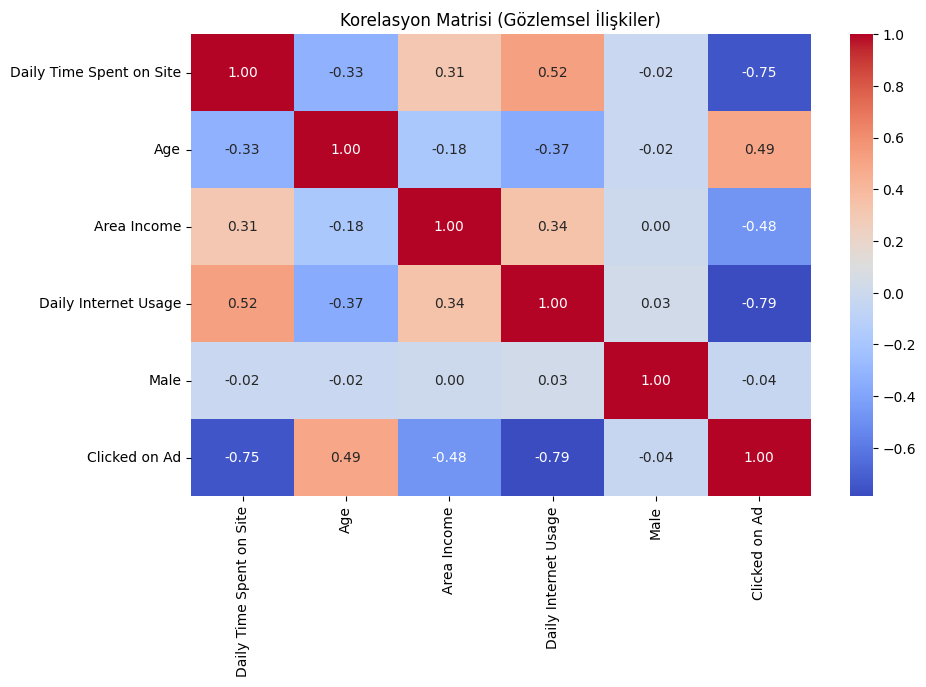

In [5]:
df = pd.read_excel("advertising.xlsx")

print("Veri Setinin İlk 5 Satırı:")
display(df.head().T)  # Transpoz alarak daha şık görünüm elde ettik

# Sayısal değişkenler arası korelasyon
plt.figure(figsize=(10,6))
sayisal_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(sayisal_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasyon Matrisi (Gözlemsel İlişkiler)')
plt.show()

In [6]:
"""
Adım 3: Özellik Mühendisliği ve Zamansal Bölünme (Temporal Split)
Veri sızıntısını (Data Leakage) önlemek için önce veriyi BÖLECEĞİZ,
ardından ön işleme (ölçeklendirme, aykırı değer) yapacağız. Gerçek dünyadaki
"zaman kaymasını" (data drift) simüle etmek için rastgele değil, ZAMANA GÖRE bölüyoruz.
"""
df_processed = df.copy()

# Zaman bilgisini ayıklama ve veriyi zamana göre sıralama
df_processed['Timestamp'] = pd.to_datetime(df_processed['Timestamp'])
df_processed = df_processed.sort_values(by='Timestamp').reset_index(drop=True)
df_processed['Hour'] = df_processed['Timestamp'].dt.hour

# Modele girmeyecek metin sütunlarını düşürme
df_model = df_processed.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)

X = df_model.drop('Clicked on Ad', axis=1)
y = df_model['Clicked on Ad']

# ÖNEMLİ: shuffle=False diyerek geçmişle eğitip geleceği test ediyoruz!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")

Eğitim Seti: (800, 6), Test Seti: (200, 6)


In [7]:
"""
Adım 4: Veri Sızıntısı Olmadan IQR Baskılama ve Standardizasyon
Aykırı değer analizini SADECE eğitim (X_train) verisinden öğrenip (fit),
Test verisinden satır kaybetmemek için alt ve üst sınırlara "Baskılama" (Capping) yapıyoruz.
"""
sayisal_sutunlar = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# IQR sınırlarını yalnızca X_train üzerinden hesapla
for sutun in sayisal_sutunlar:
    q1 = X_train_clean[sutun].quantile(0.25)
    q3 = X_train_clean[sutun].quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr

    # Test setinden veri atmamak için aykırı değerleri sınırlara sabitliyoruz (Capping)
    X_train_clean[sutun] = np.clip(X_train_clean[sutun], alt_sinir, ust_sinir)
    X_test_clean[sutun] = np.clip(X_test_clean[sutun], alt_sinir, ust_sinir)

# Ölçeklendirme (Fit işlemi SADECE Train üzerinde)
scaler = StandardScaler()
X_train_scaled = X_train_clean.copy()
X_test_scaled = X_test_clean.copy()

X_train_scaled[sayisal_sutunlar] = scaler.fit_transform(X_train_clean[sayisal_sutunlar])
X_test_scaled[sayisal_sutunlar] = scaler.transform(X_test_clean[sayisal_sutunlar])

print("Ön işleme veri sızıntısı olmadan tamamlandı!")
display(X_train_scaled.head().T)

Ön işleme veri sızıntısı olmadan tamamlandı!


,0,1,2,3,4
Daily Time Spent on Site,0.983868,0.182614,1.000957,0.863617,-1.807865
Age,-0.202785,-1.235353,0.026675,-0.891164,-0.776434
Area Income,0.263461,0.990789,0.409229,0.616653,-0.973646
Daily Internet Usage,1.374421,0.195333,1.378547,0.734220,0.368850
Male,0.000000,1.000000,0.000000,0.000000,0.000000
Hour,2.000000,3.000000,5.000000,8.000000,15.000000


In [8]:

"""
Adım 5: 5-Fold Cross Validation ile Model Eğitimi
Parametreleri keyfi belirlemek yerine GridSearchCV kullanarak algoritmaların
en optimum (bias-variance dengesi kurulmuş) hiperparametreleri bulmasını sağlıyoruz.
"""
# 1. Lojistik Regresyon
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Karar Ağacı Optimizasyonu (Aşırı öğrenmeyi / Overfitting engellemek için budama)
tree_params = {'max_depth': [3, 4, 5, 6], 'min_samples_leaf': [5, 10, 20]}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_params, cv=5, scoring='accuracy')
tree_grid.fit(X_train_scaled, y_train)
best_tree = tree_grid.best_estimator_

# 3. KNN Optimizasyonu (En iyi K değerini arama)
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_

print(f"Optimum Karar Ağacı Parametreleri: {tree_grid.best_params_}")
print(f"Optimum KNN K-Değeri: {knn_grid.best_params_}")

Optimum Karar Ağacı Parametreleri: {'max_depth': 3, 'min_samples_leaf': 10}
Optimum KNN K-Değeri: {'n_neighbors': 3}


--- Lojistik Regresyon Sonuçları ---
Accuracy: 0.9750
ROC-AUC Skoru: 0.9882

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        94
           1       0.99      0.96      0.98       106

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



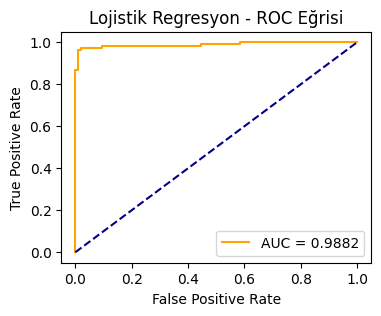

--- Karar Ağacı (Optimize Edilmiş) Sonuçları ---
Accuracy: 0.9350
ROC-AUC Skoru: 0.9799

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        94
           1       0.97      0.91      0.94       106

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



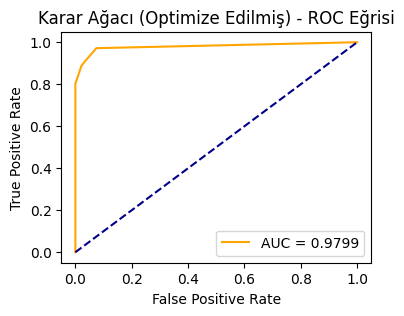

--- KNN (Optimize Edilmiş) Sonuçları ---
Accuracy: 0.9500
ROC-AUC Skoru: 0.9702

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        94
           1       0.97      0.93      0.95       106

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



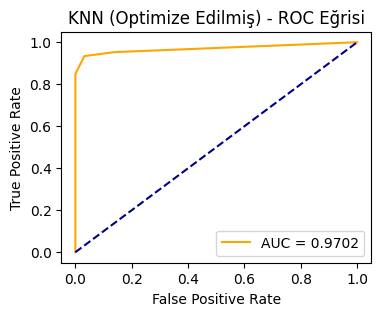

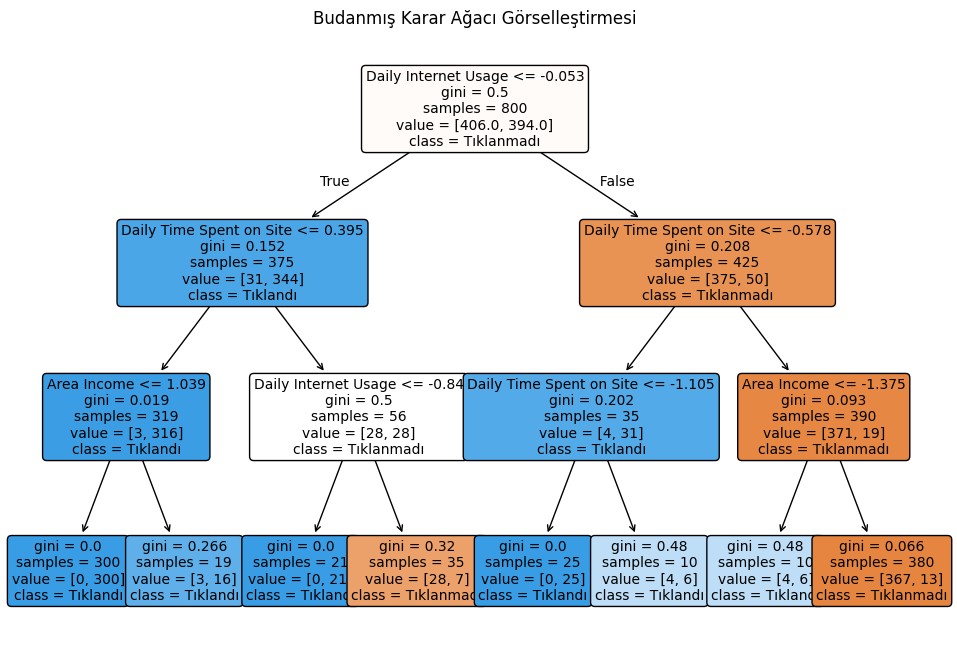

In [9]:
"""
Adım 6: Olasılık Kalibrasyonu ve Metriklerin Raporlanması
Accuracy yeterli değildir; modellerin olasılık üretme başarısını ROC-AUC ile ölçüyoruz.
"""
def model_raporla(model, X_test, y_test, model_adi):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # ROC Eğrisi için 1 sınıfının olasılıkları

    print(f"--- {model_adi} Sonuçları ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}\n")
    print("Sınıflandırma Raporu:\n", classification_report(y_test, y_pred))

    # ROC Eğrisi Çizimi
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(4,3))
    plt.plot(fpr, tpr, color='orange', label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_adi} - ROC Eğrisi')
    plt.legend()
    plt.show()

model_raporla(log_reg, X_test_scaled, y_test, "Lojistik Regresyon")
model_raporla(best_tree, X_test_scaled, y_test, "Karar Ağacı (Optimize Edilmiş)")
model_raporla(best_knn, X_test_scaled, y_test, "KNN (Optimize Edilmiş)")

# Budanmış Karar Ağacının Görseli (Artık daha sade ve açıklanabilir)
plt.figure(figsize=(12, 8))
plot_tree(best_tree, filled=True, feature_names=X.columns, class_names=['Tıklanmadı', 'Tıklandı'], rounded=True, fontsize=10)
plt.title('Budanmış Karar Ağacı Görselleştirmesi')
plt.show()